In [1]:
!nvidia-smi

Sat Jul 25 18:42:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA disponibile: True
GPU: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Running on:", device)

Running on: cuda


In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

In [5]:
transform = transforms.ToTensor()

In [6]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 467kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.6MB/s]


In [7]:
print("Immagini di training:", len(train_dataset))
print("Immagini di test:", len(test_dataset))

Immagini di training: 60000
Immagini di test: 10000


In [8]:
from torch.utils.data import DataLoader

In [9]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [10]:
images, labels = next(iter(train_loader))

print("Shape immagini:", images.shape)
print("Shape etichette:", labels.shape)

Shape immagini: torch.Size([64, 1, 28, 28])
Shape etichette: torch.Size([64])


In [11]:
import torch.nn as nn

In [12]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

In [13]:
model = NeuralNetwork()

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [14]:
model = model.to(device)

print(device)

cuda


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
import time

In [17]:
print(device)
print(torch.cuda.is_available())

cuda
True


In [18]:
print(model)
print(criterion)
print(optimizer)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [19]:
import time

def train(model, loader, criterion, optimizer, device, epochs=5):

    model.train()

    start_time = time.time()

    for epoch in range(epochs):

        running_loss = 0.0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(loader):.4f}")

    if device.type == "cuda":
        torch.cuda.synchronize()

    end_time = time.time()

    return end_time - start_time

In [20]:
def evaluate(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [21]:
training_time = train(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=5
)

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/5 - Loss: 0.3455
Epoch 2/5 - Loss: 0.1423
Epoch 3/5 - Loss: 0.0980
Epoch 4/5 - Loss: 0.0741
Epoch 5/5 - Loss: 0.0568
Training time: 40.72 seconds


In [22]:
accuracy = evaluate(
    model,
    test_loader,
    device
)

print(f"\nAccuracy: {accuracy:.2f}%")


Accuracy: 97.62%


In [23]:
import pandas as pd

results = pd.DataFrame({
    "GPU": ["NVIDIA Tesla T4"],
    "Dataset": ["MNIST"],
    "Epochs": [5],
    "Batch Size": [64],
    "Training Time (seconds)":
     [training_time],
    "Final Loss": [0.0538],
    "Accuracy (%)": [accuracy]
    })

results.to_csv("results.csv", index=False)

print(results)

               GPU Dataset  Epochs  Batch Size  Training Time (seconds)  \
0  NVIDIA Tesla T4   MNIST       5          64                40.719001   

   Final Loss  Accuracy (%)  
0      0.0538         97.62  


In [24]:
torch.save(
    model.state_dict(),
    "mnist_gpu_model.pth"
)

print("Modello salvato correttamente.")

Modello salvato correttamente.


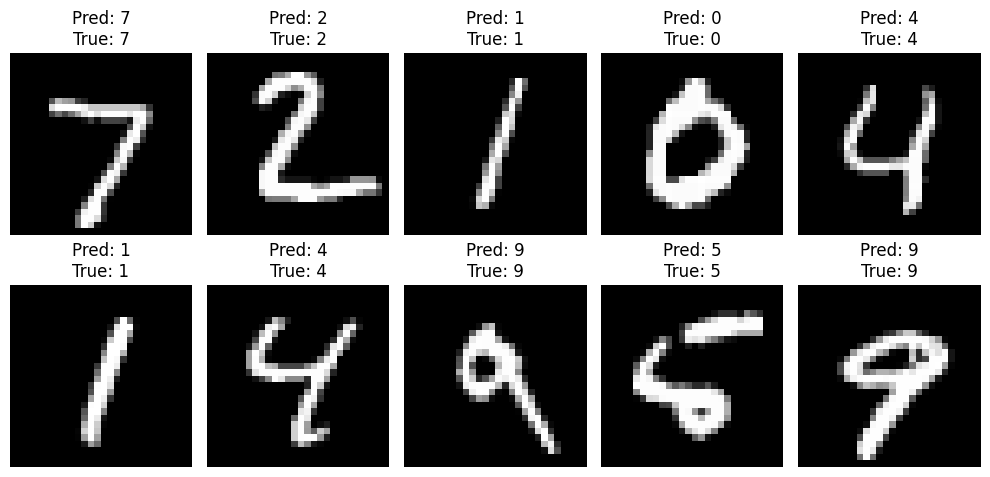

In [25]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))

images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    _, predicted = torch.max(outputs, 1)

images_cpu = images.cpu()

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(images_cpu[i].squeeze(), cmap="gray")

    plt.title(
        f"Pred: {predicted[i].item()}\nTrue: {labels[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig("predictions.png")

plt.show()

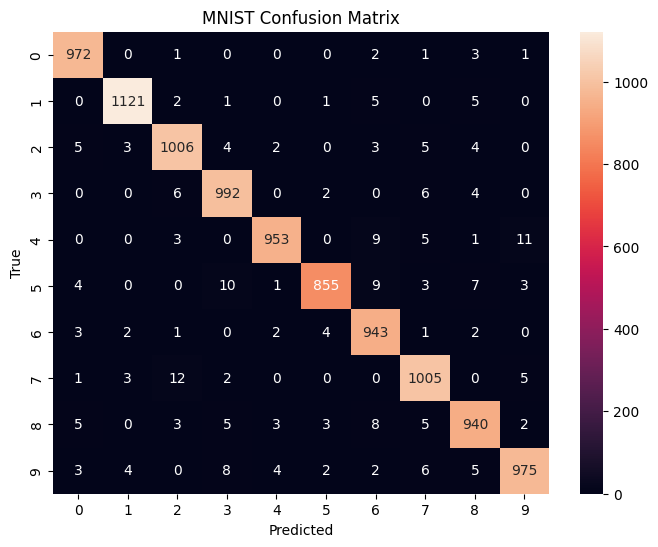

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


cm = confusion_matrix(
    all_labels,
    all_predictions
)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("MNIST Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [27]:
device = torch.device("cuda")

model_gpu = NeuralNetwork().to(device)

optimizer = torch.optim.Adam(
    model_gpu.parameters(),
    lr=0.001
)

gpu_time = train(
    model_gpu,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=5
)

gpu_accuracy = evaluate(
    model_gpu,
    test_loader,
    device
)

print("GPU time:", gpu_time)
print("GPU accuracy:", gpu_accuracy)

Epoch 1/5 - Loss: 0.3434
Epoch 2/5 - Loss: 0.1410
Epoch 3/5 - Loss: 0.0993
Epoch 4/5 - Loss: 0.0735
Epoch 5/5 - Loss: 0.0584
GPU time: 40.68405246734619
GPU accuracy: 97.6


In [28]:
device_cpu = torch.device("cpu")

model_cpu = NeuralNetwork().to(device_cpu)

optimizer_cpu = torch.optim.Adam(
    model_cpu.parameters(),
    lr=0.001
)

cpu_time = train(
    model_cpu,
    train_loader,
    criterion,
    optimizer_cpu,
    device_cpu,
    epochs=5
)

cpu_accuracy = evaluate(
    model_cpu,
    test_loader,
    device_cpu
)

print("CPU time:", cpu_time)
print("CPU accuracy:", cpu_accuracy)

Epoch 1/5 - Loss: 0.3361
Epoch 2/5 - Loss: 0.1405
Epoch 3/5 - Loss: 0.0973
Epoch 4/5 - Loss: 0.0743
Epoch 5/5 - Loss: 0.0584
CPU time: 45.54170036315918
CPU accuracy: 97.2


In [29]:
print("="*40)
print("FINAL RESULTS")
print("="*40)

print(f"GPU time : {gpu_time:.2f} s")
print(f"GPU accuracy : {gpu_accuracy:.2f}%")

print()

print(f"CPU time : {cpu_time:.2f} s")
print(f"CPU accuracy : {cpu_accuracy:.2f}%")

print()

print(f"GPU speedup: {cpu_time/gpu_time:.2f}x")

FINAL RESULTS
GPU time : 40.68 s
GPU accuracy : 97.60%

CPU time : 45.54 s
CPU accuracy : 97.20%

GPU speedup: 1.12x
